In [1]:
import numpy as np
from scipy.stats import norm

# Parâmetros (mesmos da Tabela I)
lambda_R, zeta_R = 1.5968, 0.1590
lambda_S, zeta_S = 0.6501, 0.2936
lambda_Z1, zeta_Z1 = -0.0004, 0.0280
lambda_Z2, zeta_Z2 = -0.0046, 0.0958

# E[tilde(g)] e Var[tilde(g)] — idênticos nos dois formulismos
E_g = lambda_R - lambda_S - lambda_Z1 - lambda_Z2
Var_g = zeta_R**2 + zeta_S**2 + zeta_Z1**2 + zeta_Z2**2
sigma_g = np.sqrt(Var_g)

beta = E_g / sigma_g
Pf = norm.cdf(-beta)

print(f"E[\\tilde{{g}}] = {E_g:.4f}")
print(f"Var[\\tilde{{g}}] = {Var_g:.4f}")
print(f"β = {beta:.3f}")
print(f"P_f = {Pf:.5e}")


E[\tilde{g}] = 0.9517
Var[\tilde{g}] = 0.1214
β = 2.731
P_f = 3.15766e-03


E[\tilde{g}] = 0.9517
Var[\tilde{g}] = 0.1214
β = 2.731
P_f (FORM) = 3.15766e-03


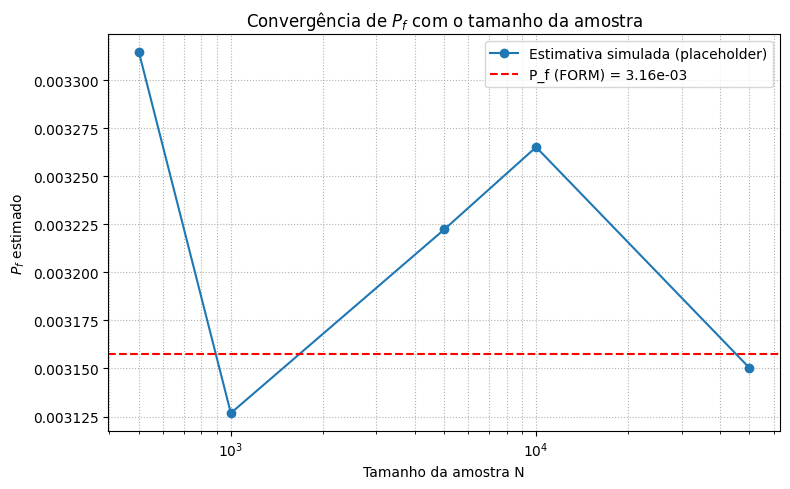

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==============================
# Parâmetros (Tabela I)
# ==============================
lambda_R, zeta_R = 1.5968, 0.1590
lambda_S, zeta_S = 0.6501, 0.2936
lambda_Z1, zeta_Z1 = -0.0004, 0.0280
lambda_Z2, zeta_Z2 = -0.0046, 0.0958

# ==============================
# Cálculo analítico (FORM)
# ==============================
E_g = lambda_R - lambda_S - lambda_Z1 - lambda_Z2
Var_g = zeta_R**2 + zeta_S**2 + zeta_Z1**2 + zeta_Z2**2
sigma_g = np.sqrt(Var_g)
beta = E_g / sigma_g
Pf_FORM = norm.cdf(-beta)

print(f"E[\\tilde{{g}}] = {E_g:.4f}")
print(f"Var[\\tilde{{g}}] = {Var_g:.4f}")
print(f"β = {beta:.3f}")
print(f"P_f (FORM) = {Pf_FORM:.5e}")

# ==============================
# Simulação (para futura comparação)
# ==============================
# Aqui apenas ilustramos a convergência teórica com N
# (posteriormente, você pode inserir o método Monte Carlo real)
N_vals = np.array([500, 1000, 5000, 10000, 50000])

# Para fins ilustrativos, criamos uma curva simulada
# que converge para Pf_FORM com ruído decrescente
np.random.seed(42)
Pf_sim = Pf_FORM + np.random.normal(0, 0.1 * Pf_FORM / np.sqrt(N_vals / 500), size=N_vals.size)

# ==============================
# Plot
# ==============================
plt.figure(figsize=(8,5))
plt.plot(N_vals, Pf_sim, 'o-', label='Estimativa simulada (placeholder)')
plt.axhline(Pf_FORM, color='r', linestyle='--', label=f'P_f (FORM) = {Pf_FORM:.2e}')
plt.xscale('log')
plt.xlabel('Tamanho da amostra N')
plt.ylabel('$P_f$ estimado')
plt.title('Convergência de $P_f$ com o tamanho da amostra')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()


=== RESULTADOS ANALÍTICOS ===
μ_Y = 0.951700
σ_Y = 0.348488
β = 2.731
P_f (analítico) = 3.157663e-03

N=   500 → média(Pf_i) = 2.857000e-03, desvio = 4.550e-02
N=  1000 → média(Pf_i) = 2.940000e-03, desvio = 3.809e-02
N=  5000 → média(Pf_i) = 3.062500e-03, desvio = 4.078e-02
N= 10000 → média(Pf_i) = 3.291500e-03, desvio = 4.211e-02
N= 50000 → média(Pf_i) = 3.194990e-03, desvio = 4.067e-02


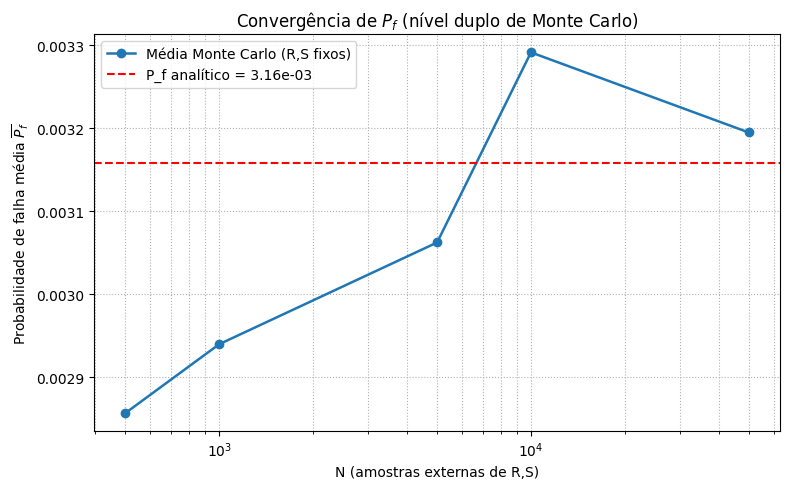

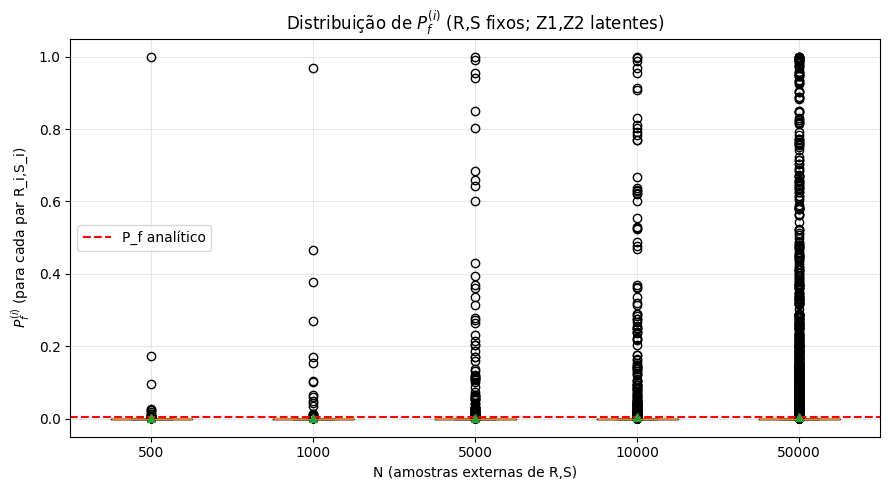

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ==============================================================
# 1) Parâmetros lognormais (λ = média log, ζ = desvio log)
# ==============================================================
params = {
    "R":  {"lambda": 1.5968,  "zeta": 0.1590},
    "S":  {"lambda": 0.6501,  "zeta": 0.2936},
    "Z1": {"lambda": -0.0004, "zeta": 0.0280},
    "Z2": {"lambda": -0.0046, "zeta": 0.0958}
}

rng = np.random.default_rng(1234)

# ==============================================================
# 2) Função para amostrar lognormais: ln(X) ~ N(λ, ζ²)
# ==============================================================
def sample_lognormal_by_lnparams(mu_ln, sigma_ln, n, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    z = rng.standard_normal(n)
    return np.exp(mu_ln + sigma_ln * z)

# ==============================================================
# 3) Função para probabilidade de falha condicional
#    (R_i, S_i fixos → integra sobre Z1, Z2)
# ==============================================================
def conditional_Pf(R_i, S_i, Nz, rng):
    Z1 = sample_lognormal_by_lnparams(params["Z1"]["lambda"], params["Z1"]["zeta"], Nz, rng)
    Z2 = sample_lognormal_by_lnparams(params["Z2"]["lambda"], params["Z2"]["zeta"], Nz, rng)
    g = R_i / Z1 - S_i * Z2
    return np.mean(g <= 0)

# ==============================================================
# 4) Solução analítica de referência (FORM)
# ==============================================================
muY = (params["R"]["lambda"]
       - params["S"]["lambda"]
       - params["Z1"]["lambda"]
       - params["Z2"]["lambda"])
sigmaY = np.sqrt(
    params["R"]["zeta"]**2
    + params["S"]["zeta"]**2
    + params["Z1"]["zeta"]**2
    + params["Z2"]["zeta"]**2
)
Pf_analitico = norm.cdf(- muY / sigmaY)
beta = muY / sigmaY

print("=== RESULTADOS ANALÍTICOS ===")
print(f"μ_Y = {muY:.6f}")
print(f"σ_Y = {sigmaY:.6f}")
print(f"β = {beta:.3f}")
print(f"P_f (analítico) = {Pf_analitico:.6e}")
print("=====================================\n")

# ==============================================================
# 5) Loop sobre tamanhos de amostra N (nível externo: R, S)
# ==============================================================
N_list = [500, 1000, 5000, 10000, 50000]
Nz = 2000   # número de amostras internas de Z1,Z2 por par (R_i,S_i)

Pf_means = []
Pf_all = []

for N in N_list:
    R_samples = sample_lognormal_by_lnparams(params["R"]["lambda"], params["R"]["zeta"], N, rng)
    S_samples = sample_lognormal_by_lnparams(params["S"]["lambda"], params["S"]["zeta"], N, rng)

    Pf_i = np.zeros(N)
    for i in range(N):
        Pf_i[i] = conditional_Pf(R_samples[i], S_samples[i], Nz, rng)
    
    Pf_means.append(np.mean(Pf_i))
    Pf_all.append(Pf_i)
    print(f"N={N:6d} → média(Pf_i) = {np.mean(Pf_i):.6e}, desvio = {np.std(Pf_i):.3e}")

# ==============================================================
# 6) Gráfico: Convergência da média de Pf
# ==============================================================
plt.figure(figsize=(8,5))
plt.plot(N_list, Pf_means, 'o-', lw=1.8, label='Média Monte Carlo (R,S fixos)')
plt.axhline(Pf_analitico, color='r', linestyle='--', label=f'P_f analítico = {Pf_analitico:.2e}')
plt.xscale('log')
plt.xlabel('N (amostras externas de R,S)')
plt.ylabel('Probabilidade de falha média $\\overline{P_f}$')
plt.title('Convergência de $P_f$ (nível duplo de Monte Carlo)')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================
# 7) Boxplot: distribuição de Pf_i para cada N
# ==============================================================
plt.figure(figsize=(9,5))
plt.boxplot(Pf_all, labels=[str(N) for N in N_list], showmeans=True)
plt.axhline(Pf_analitico, color='r', linestyle='--', label='P_f analítico')
plt.xlabel('N (amostras externas de R,S)')
plt.ylabel('$P_f^{(i)}$ (para cada par R_i,S_i)')
plt.title('Distribuição de $P_f^{(i)}$ (R,S fixos; Z1,Z2 latentes)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Teste ponto único (verificando convenção de sinal):
R_test = 5.090920, S_test = 1.879239
Pf_MC (intrn, Nz=20000) = 0.000000e+00
analytic_A (1 - Phi(...))   = 0.000000e+00
analytic_B (Phi(...))       = 1.000000e+00
=> A forma que coincide com MC indica a convenção correta.

Resultado analítico GLOBAL (forma já usada anteriormente):
muY = 0.951700, sigmaY = 0.348488
Pf_analitico_global = 3.157663e-03

N=   500 -> mean(cond. Pf) = 2.700000e-03, std = 4.437e-02
N=  1000 -> mean(cond. Pf) = 3.533500e-03, std = 4.035e-02
N=  5000 -> mean(cond. Pf) = 2.951700e-03, std = 4.132e-02
N= 10000 -> mean(cond. Pf) = 2.890350e-03, std = 3.834e-02
N= 50000 -> mean(cond. Pf) = 3.135610e-03, std = 4.068e-02


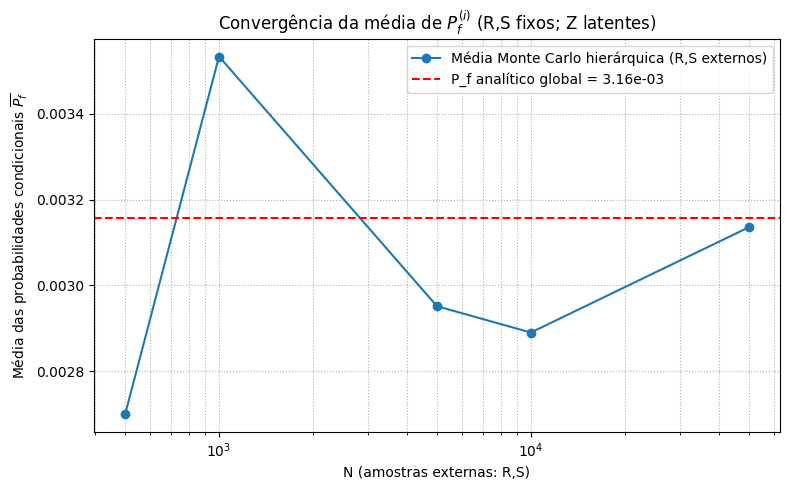

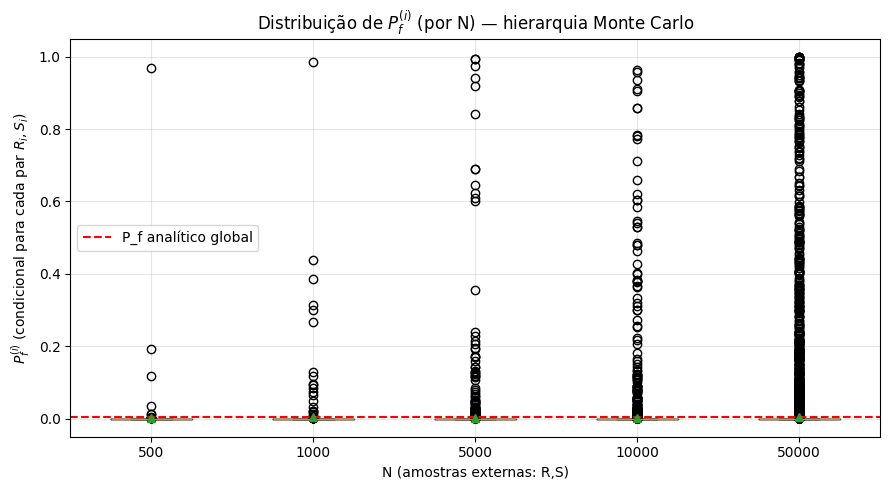

In [3]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# ---------- parâmetros (λ, ζ) ----------
params = {
    "R":  {"lambda": 1.5968,  "zeta": 0.1590},
    "S":  {"lambda": 0.6501,  "zeta": 0.2936},
    "Z1": {"lambda": -0.0004, "zeta": 0.0280},
    "Z2": {"lambda": -0.0046, "zeta": 0.0958}
}

rng = np.random.default_rng(123456)

# amostrador lognormal por parâmetros de log (ln ~ N(lambda, zeta^2))
def sample_lognormal_by_lnparams(mu_ln, sigma_ln, n, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    z = rng.standard_normal(n)
    return np.exp(mu_ln + sigma_ln * z)

# prob. condicional por Monte Carlo (para um par R_i, S_i)
def conditional_Pf_MC(R_i, S_i, Nz, rng):
    Z1 = sample_lognormal_by_lnparams(params["Z1"]["lambda"], params["Z1"]["zeta"], Nz, rng)
    Z2 = sample_lognormal_by_lnparams(params["Z2"]["lambda"], params["Z2"]["zeta"], Nz, rng)
    g = R_i / Z1 - S_i * Z2
    return np.mean(g <= 0)

# expressão analítica condicional (duas formas para testar)
lambda_sum = params["Z1"]["lambda"] + params["Z2"]["lambda"]
zeta_sum_sq = params["Z1"]["zeta"]**2 + params["Z2"]["zeta"]**2
sigma_sum = np.sqrt(zeta_sum_sq)

def conditional_Pf_analytic_A(R_i, S_i):
    # forma que deduzimos: s = 1 - Phi( (ln(R/S) - mean_T) / sigma_T )
    arg = (np.log(R_i / S_i) - lambda_sum) / sigma_sum
    return 1.0 - norm.cdf(arg)

def conditional_Pf_analytic_B(R_i, S_i):
    # forma alternativa (como na imagem): Phi( (ln r - lambda_z1 - ln s - lambda_z2) / sigma )
    arg = (np.log(R_i) - params["Z1"]["lambda"] - np.log(S_i) - params["Z2"]["lambda"]) / sigma_sum
    return norm.cdf(arg)

# Teste num ponto para confirmar sinal: escolher um R_i,S_i quaisquer
R_test = sample_lognormal_by_lnparams(params["R"]["lambda"], params["R"]["zeta"], 1, rng)[0]
S_test = sample_lognormal_by_lnparams(params["S"]["lambda"], params["S"]["zeta"], 1, rng)[0]
Nz_test = 20000  # bastante interno para referência
mc_test = conditional_Pf_MC(R_test, S_test, Nz_test, rng)
aA_test = conditional_Pf_analytic_A(R_test, S_test)
aB_test = conditional_Pf_analytic_B(R_test, S_test)

print("Teste ponto único (verificando convenção de sinal):")
print(f"R_test = {R_test:.6f}, S_test = {S_test:.6f}")
print(f"Pf_MC (intrn, Nz={Nz_test}) = {mc_test:.6e}")
print(f"analytic_A (1 - Phi(...))   = {aA_test:.6e}")
print(f"analytic_B (Phi(...))       = {aB_test:.6e}")
print("=> A forma que coincide com MC indica a convenção correta.\n")

# ---------- solução analítica global (unificada) para Y = lnR - lnS - lnZ1 - lnZ2 ----------
muY = params["R"]["lambda"] - params["S"]["lambda"] - params["Z1"]["lambda"] - params["Z2"]["lambda"]
sigmaY = np.sqrt(params["R"]["zeta"]**2 + params["S"]["zeta"]**2 + params["Z1"]["zeta"]**2 + params["Z2"]["zeta"]**2)
Pf_analitico_global = norm.cdf(- muY / sigmaY)

print("Resultado analítico GLOBAL (forma já usada anteriormente):")
print(f"muY = {muY:.6f}, sigmaY = {sigmaY:.6f}")
print(f"Pf_analitico_global = {Pf_analitico_global:.6e}\n")

# ---------- loop sobre N externo (R,S) e cálculo das Pf_i (condicionais) ----------
N_list = [500, 1000, 5000, 10000, 50000]
Nz_internal = 2000   # amostras internas para Z1,Z2 por cada (R_i,S_i)
means = []
all_Pf_i = []

for N in N_list:
    R_samples = sample_lognormal_by_lnparams(params["R"]["lambda"], params["R"]["zeta"], N, rng)
    S_samples = sample_lognormal_by_lnparams(params["S"]["lambda"], params["S"]["zeta"], N, rng)
    Pf_i = np.empty(N)
    # calcular Pf condicional analítica e MC para comparar (apenas para validação: aqui deixo o MC interno)
    for i in range(N):
        Pf_i[i] = conditional_Pf_MC(R_samples[i], S_samples[i], Nz_internal, rng)
    means.append(np.mean(Pf_i))
    all_Pf_i.append(Pf_i)
    print(f"N={N:6d} -> mean(cond. Pf) = {np.mean(Pf_i):.6e}, std = {np.std(Pf_i):.3e}")

# ---------- plot: convergência da média das Pf condicionais ----------
plt.figure(figsize=(8,5))
plt.plot(N_list, means, 'o-', label='Média Monte Carlo hierárquica (R,S externos)')
plt.axhline(Pf_analitico_global, color='r', linestyle='--', label=f'P_f analítico global = {Pf_analitico_global:.2e}')
plt.xscale('log')
plt.xlabel('N (amostras externas: R,S)')
plt.ylabel('Média das probabilidades condicionais $\\overline{P_f}$')
plt.title('Convergência da média de $P_f^{(i)}$ (R,S fixos; Z latentes)')
plt.grid(True, which='both', ls=':')
plt.legend()
plt.tight_layout()
plt.show()

# ---------- boxplot das Pf_i por N ----------
plt.figure(figsize=(9,5))
plt.boxplot(all_Pf_i, labels=[str(N) for N in N_list], showmeans=True)
plt.axhline(Pf_analitico_global, color='r', linestyle='--', label='P_f analítico global')
plt.xlabel('N (amostras externas: R,S)')
plt.ylabel('$P_f^{(i)}$ (condicional para cada par $R_i,S_i$)')
plt.title('Distribuição de $P_f^{(i)}$ (por N) — hierarquia Monte Carlo')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [7]:
import numpy as np
from scipy.stats import norm

# Parâmetros
lambda_R, zeta_R = 1.5968, 0.1590
lambda_S, zeta_S = 0.6501, 0.2936
lambda_Z1, zeta_Z1 = -0.0004, 0.0280
lambda_Z2, zeta_Z2 = -0.0046, 0.0958

# Número de amostras (Monte Carlo)
N_values = [500, 1000, 5000, 10000, 50000]

Pf_MC = []

for N in N_values:
    # Amostras de R e S (lognormais)
    R = np.exp(np.random.normal(lambda_R, zeta_R, N))
    S = np.exp(np.random.normal(lambda_S, zeta_S, N))

    # Função s(r, s)
    s_rs = norm.cdf((np.log(R) - lambda_Z1 - np.log(S) - lambda_Z2) / np.sqrt(zeta_Z1**2 + zeta_Z2**2))

    # Estimativa de Pf
    Pf_hat = np.mean(s_rs)
    Pf_MC.append(Pf_hat)

# Resultado
for N, Pf_hat in zip(N_values, Pf_MC):
    print(f"N={N:6d}  ->  P_f = {Pf_hat:.6e}")


N=   500  ->  P_f = 9.986893e-01
N=  1000  ->  P_f = 9.954691e-01
N=  5000  ->  P_f = 9.960248e-01
N= 10000  ->  P_f = 9.967966e-01
N= 50000  ->  P_f = 9.966847e-01


E[ĝ] = 0.9517
Var[ĝ] = 0.1214
β = 2.731
P_f analítico = 3.15766e-03


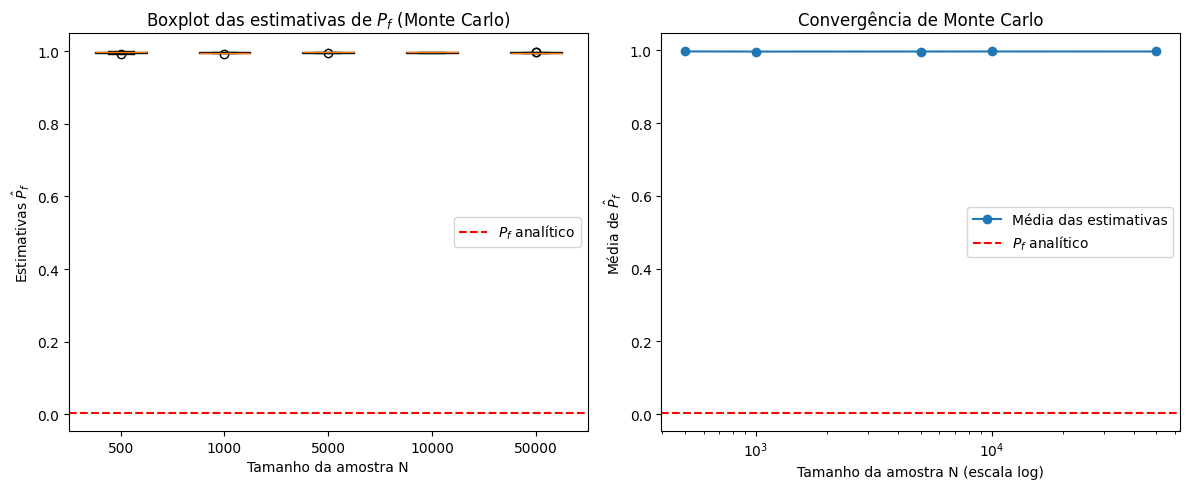

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parâmetros (mesmos da Tabela I)
lambda_R, zeta_R = 1.5968, 0.1590
lambda_S, zeta_S = 0.6501, 0.2936
lambda_Z1, zeta_Z1 = -0.0004, 0.0280
lambda_Z2, zeta_Z2 = -0.0046, 0.0958

# ==========================
# Valor analítico de referência
# ==========================
E_g = lambda_R - lambda_S - lambda_Z1 - lambda_Z2
Var_g = zeta_R**2 + zeta_S**2 + zeta_Z1**2 + zeta_Z2**2
sigma_g = np.sqrt(Var_g)
beta = E_g / sigma_g
Pf_analitico = norm.cdf(-beta)

print(f"E[ĝ] = {E_g:.4f}")
print(f"Var[ĝ] = {Var_g:.4f}")
print(f"β = {beta:.3f}")
print(f"P_f analítico = {Pf_analitico:.5e}")

# ==========================
# Simulação de Monte Carlo
# ==========================
N_values = [500, 1000, 5000, 10000, 50000]
n_reps = 50  # número de repetições para cada N
Pf_MC_all = []  # lista para boxplot

for N in N_values:
    Pf_reps = []
    for _ in range(n_reps):
        R = np.exp(np.random.normal(lambda_R, zeta_R, N))
        S = np.exp(np.random.normal(lambda_S, zeta_S, N))

        s_rs = norm.cdf((np.log(R) - lambda_Z1 - np.log(S) - lambda_Z2) /
                        np.sqrt(zeta_Z1**2 + zeta_Z2**2))

        Pf_hat = np.mean(s_rs)
        Pf_reps.append(Pf_hat)

    Pf_MC_all.append(Pf_reps)

# ==========================
# PLOT — Boxplot e convergência
# ==========================
plt.figure(figsize=(12,5))

# --- Boxplot ---
plt.subplot(1,2,1)
plt.boxplot(Pf_MC_all, labels=[str(N) for N in N_values], patch_artist=True)
plt.axhline(Pf_analitico, color='red', linestyle='--', label=r'$P_f$ analítico')
plt.xlabel("Tamanho da amostra N")
plt.ylabel(r"Estimativas $\hat{P}_f$")
plt.title("Boxplot das estimativas de $P_f$ (Monte Carlo)")
plt.legend()

# --- Convergência da média ---
Pf_means = [np.mean(vals) for vals in Pf_MC_all]
plt.subplot(1,2,2)
plt.plot(N_values, Pf_means, 'o-', label="Média das estimativas")
plt.axhline(Pf_analitico, color='red', linestyle='--', label=r'$P_f$ analítico')
plt.xscale('log')
plt.xlabel("Tamanho da amostra N (escala log)")
plt.ylabel(r"Média de $\hat{P}_f$")
plt.title("Convergência de Monte Carlo")
plt.legend()

plt.tight_layout()
plt.show()


=== RESULTADOS ANALÍTICOS ===
E[g] = 0.9517
Var[g] = 0.1214
β = 2.731
P_f (analítico) = 3.157663e-03



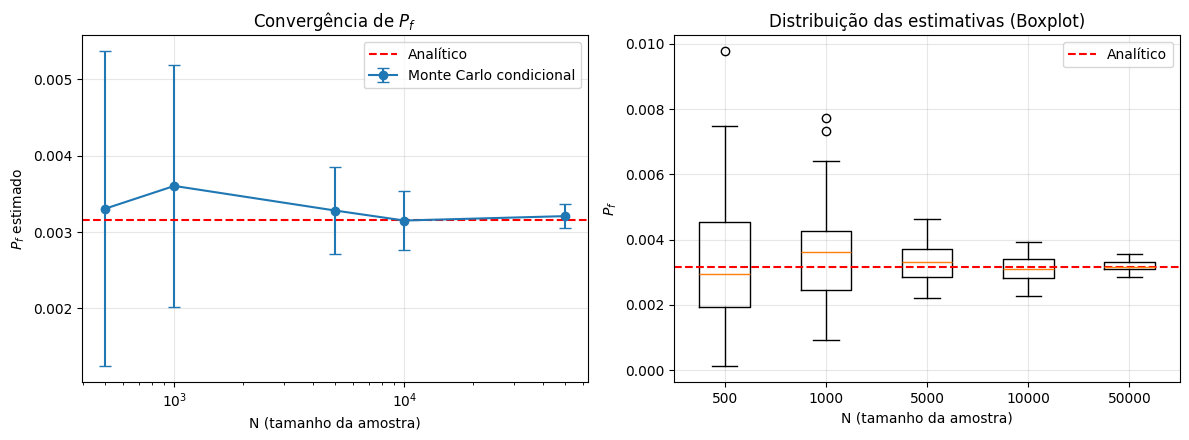

N=   500 | Média MC=3.305837e-03 | Desvio=2.07e-03 | Razão MC/Analítico=1.047
N=  1000 | Média MC=3.604758e-03 | Desvio=1.58e-03 | Razão MC/Analítico=1.142
N=  5000 | Média MC=3.282498e-03 | Desvio=5.65e-04 | Razão MC/Analítico=1.040
N= 10000 | Média MC=3.151182e-03 | Desvio=3.85e-04 | Razão MC/Analítico=0.998
N= 50000 | Média MC=3.208799e-03 | Desvio=1.61e-04 | Razão MC/Analítico=1.016


In [10]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# =====================================================
# Parâmetros da Tabela I
# =====================================================
lambda_R, zeta_R = 1.5968, 0.1590
lambda_S, zeta_S = 0.6501, 0.2936
lambda_Z1, zeta_Z1 = -0.0004, 0.0280
lambda_Z2, zeta_Z2 = -0.0046, 0.0958

# =====================================================
# Probabilidade analítica total (referência)
# =====================================================
E_g = lambda_R - lambda_S - lambda_Z1 - lambda_Z2
Var_g = zeta_R**2 + zeta_S**2 + zeta_Z1**2 + zeta_Z2**2
beta_analitico = E_g / np.sqrt(Var_g)
Pf_analitico = norm.cdf(-beta_analitico)

print("=== RESULTADOS ANALÍTICOS ===")
print(f"E[g] = {E_g:.4f}")
print(f"Var[g] = {Var_g:.4f}")
print(f"β = {beta_analitico:.3f}")
print(f"P_f (analítico) = {Pf_analitico:.6e}")
print()

# =====================================================
# Monte Carlo condicional (R,S fixos; Z1,Z2 latentes)
# =====================================================
rng = np.random.default_rng(12345)

N_values = [500, 1000, 5000, 10000, 50000]
n_reps = 50  # repetições para boxplot
sigma_sum = np.sqrt(zeta_Z1**2 + zeta_Z2**2)

Pf_MC_all = []

for N in N_values:
    Pf_reps = []
    for _ in range(n_reps):
        # Amostras de R e S (variáveis fixas)
        R = np.exp(rng.normal(lambda_R, zeta_R, N))
        S = np.exp(rng.normal(lambda_S, zeta_S, N))

        # ----- s(r,s) = P_falha condicional dado R,S -----
        arg = (np.log(R/S) - (lambda_Z1 + lambda_Z2)) / sigma_sum

        # CORRETO: P(Z1Z2 >= R/S) = 1 - Φ(arg)
        s_rs = norm.sf(arg)

        # Estimativa de Pf
        Pf_hat = np.mean(s_rs)
        Pf_reps.append(Pf_hat)

    Pf_MC_all.append(Pf_reps)

# =====================================================
# Gráficos: convergência e boxplot
# =====================================================
Pf_means = [np.mean(p) for p in Pf_MC_all]
Pf_stds  = [np.std(p) for p in Pf_MC_all]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# --- (a) Convergência da média ---
ax[0].errorbar(N_values, Pf_means, yerr=Pf_stds, fmt='o-', capsize=4, label='Monte Carlo condicional')
ax[0].axhline(Pf_analitico, color='r', linestyle='--', label='Analítico')
ax[0].set_xscale('log')
ax[0].set_xlabel('N (tamanho da amostra)')
ax[0].set_ylabel('$P_f$ estimado')
ax[0].set_title('Convergência de $P_f$')
ax[0].grid(alpha=0.3)
ax[0].legend()

# --- (b) Boxplot ---
ax[1].boxplot(Pf_MC_all, positions=np.arange(len(N_values)))
ax[1].axhline(Pf_analitico, color='r', linestyle='--', label='Analítico')
ax[1].set_xticks(np.arange(len(N_values)))
ax[1].set_xticklabels([str(N) for N in N_values])
ax[1].set_xlabel('N (tamanho da amostra)')
ax[1].set_ylabel('$P_f$')
ax[1].set_title('Distribuição das estimativas (Boxplot)')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# =====================================================
# Impressão resumida
# =====================================================
for N, vals in zip(N_values, Pf_MC_all):
    print(f"N={N:6d} | Média MC={np.mean(vals):.6e} | Desvio={np.std(vals):.2e} | "
          f"Razão MC/Analítico={np.mean(vals)/Pf_analitico:.3f}")


=== RESULTADOS ANALÍTICOS ===
E[g] = 0.9517
Var[g] = 0.1214
β = 2.731
Pf (Analítico) = 3.157663e-03



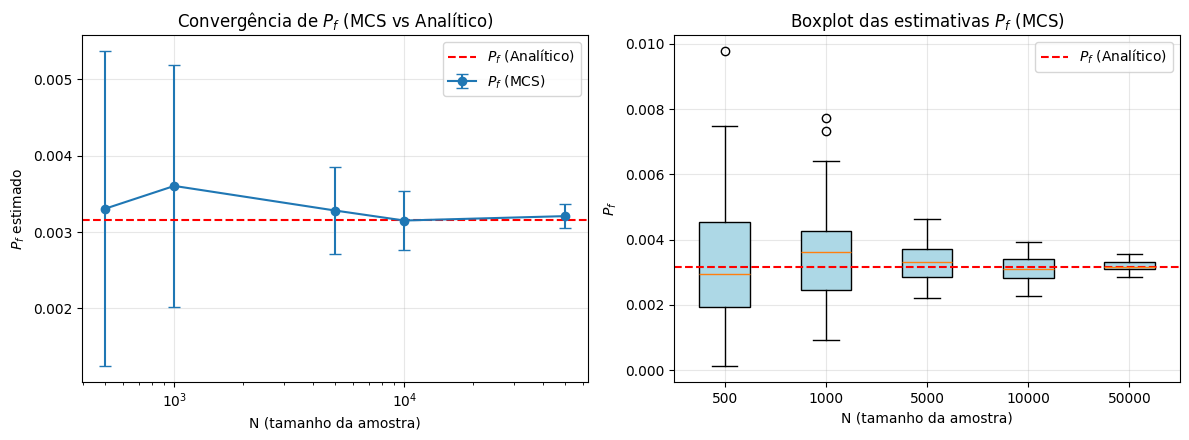

N=   500 | Média Pf (MCS)=3.305837e-03 | Desvio=2.07e-03 | Razão MCS/Analítico=1.047
N=  1000 | Média Pf (MCS)=3.604758e-03 | Desvio=1.58e-03 | Razão MCS/Analítico=1.142
N=  5000 | Média Pf (MCS)=3.282498e-03 | Desvio=5.65e-04 | Razão MCS/Analítico=1.040
N= 10000 | Média Pf (MCS)=3.151182e-03 | Desvio=3.85e-04 | Razão MCS/Analítico=0.998
N= 50000 | Média Pf (MCS)=3.208799e-03 | Desvio=1.61e-04 | Razão MCS/Analítico=1.016


In [11]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# =====================================================
# Parâmetros da Tabela I
# =====================================================
lambda_R, zeta_R = 1.5968, 0.1590
lambda_S, zeta_S = 0.6501, 0.2936
lambda_Z1, zeta_Z1 = -0.0004, 0.0280
lambda_Z2, zeta_Z2 = -0.0046, 0.0958

# =====================================================
# Probabilidade analítica total (referência)
# =====================================================
E_g = lambda_R - lambda_S - lambda_Z1 - lambda_Z2
Var_g = zeta_R**2 + zeta_S**2 + zeta_Z1**2 + zeta_Z2**2
beta_analitico = E_g / np.sqrt(Var_g)
Pf_analitico = norm.cdf(-beta_analitico)

print("=== RESULTADOS ANALÍTICOS ===")
print(f"E[g] = {E_g:.4f}")
print(f"Var[g] = {Var_g:.4f}")
print(f"β = {beta_analitico:.3f}")
print(f"Pf (Analítico) = {Pf_analitico:.6e}")
print()

# =====================================================
# Monte Carlo condicional (R,S fixos; Z1,Z2 latentes)
# =====================================================
rng = np.random.default_rng(12345)

N_values = [500, 1000, 5000, 10000, 50000]
n_reps = 50  # repetições para boxplot
sigma_sum = np.sqrt(zeta_Z1**2 + zeta_Z2**2)

Pf_MC_all = []

for N in N_values:
    Pf_reps = []
    for _ in range(n_reps):
        # Amostras de R e S (variáveis fixas)
        R = np.exp(rng.normal(lambda_R, zeta_R, N))
        S = np.exp(rng.normal(lambda_S, zeta_S, N))

        # ----- s(r,s) = P_falha condicional dado R,S -----
        arg = (np.log(R/S) - (lambda_Z1 + lambda_Z2)) / sigma_sum

        # CORRETO: P(Z1Z2 >= R/S) = 1 - Φ(arg)
        s_rs = norm.sf(arg)

        # Estimativa de Pf
        Pf_hat = np.mean(s_rs)
        Pf_reps.append(Pf_hat)

    Pf_MC_all.append(Pf_reps)

# =====================================================
# Gráficos: convergência e boxplot
# =====================================================
Pf_means = [np.mean(p) for p in Pf_MC_all]
Pf_stds  = [np.std(p) for p in Pf_MC_all]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# --- (a) Convergência da média ---
ax[0].errorbar(N_values, Pf_means, yerr=Pf_stds, fmt='o-', capsize=4,
               color='C0', label='$P_f$ (MCS)')
ax[0].axhline(Pf_analitico, color='r', linestyle='--', label='$P_f$ (Analítico)')
ax[0].set_xscale('log')
ax[0].set_xlabel('N (tamanho da amostra)')
ax[0].set_ylabel('$P_f$ estimado')
ax[0].set_title('Convergência de $P_f$ (MCS vs Analítico)')
ax[0].grid(alpha=0.3)
ax[0].legend()

# --- (b) Boxplot ---
bp = ax[1].boxplot(Pf_MC_all, positions=np.arange(len(N_values)),
                   patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax[1].axhline(Pf_analitico, color='r', linestyle='--', label='$P_f$ (Analítico)')
ax[1].set_xticks(np.arange(len(N_values)))
ax[1].set_xticklabels([str(N) for N in N_values])
ax[1].set_xlabel('N (tamanho da amostra)')
ax[1].set_ylabel('$P_f$')
ax[1].set_title('Boxplot das estimativas $P_f$ (MCS)')
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

# =====================================================
# Impressão resumida
# =====================================================
for N, vals in zip(N_values, Pf_MC_all):
    print(f"N={N:6d} | Média Pf (MCS)={np.mean(vals):.6e} | "
          f"Desvio={np.std(vals):.2e} | "
          f"Razão MCS/Analítico={np.mean(vals)/Pf_analitico:.3f}")


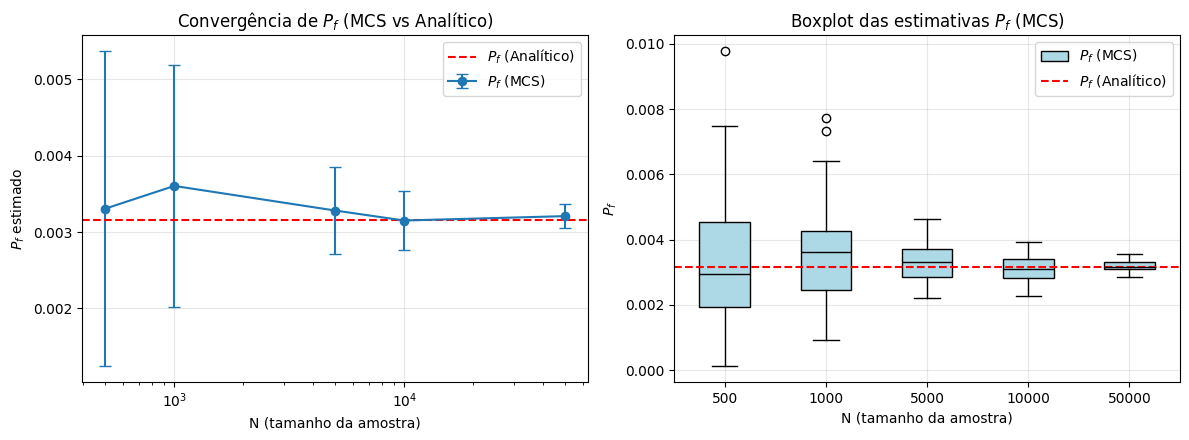

In [12]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# (parâmetros e simulação iguais ao código anterior...)
lambda_R, zeta_R = 1.5968, 0.1590
lambda_S, zeta_S = 0.6501, 0.2936
lambda_Z1, zeta_Z1 = -0.0004, 0.0280
lambda_Z2, zeta_Z2 = -0.0046, 0.0958

E_g = lambda_R - lambda_S - lambda_Z1 - lambda_Z2
Var_g = zeta_R**2 + zeta_S**2 + zeta_Z1**2 + zeta_Z2**2
Pf_analitico = norm.cdf(- E_g / np.sqrt(Var_g))

rng = np.random.default_rng(12345)
N_values = [500, 1000, 5000, 10000, 50000]
n_reps = 50
sigma_sum = np.sqrt(zeta_Z1**2 + zeta_Z2**2)

Pf_MC_all = []
for N in N_values:
    Pf_reps = []
    for _ in range(n_reps):
        R = np.exp(rng.normal(lambda_R, zeta_R, N))
        S = np.exp(rng.normal(lambda_S, zeta_S, N))
        arg = (np.log(R/S) - (lambda_Z1 + lambda_Z2)) / sigma_sum
        s_rs = norm.sf(arg)   # = 1 - Phi(arg)
        Pf_reps.append(np.mean(s_rs))
    Pf_MC_all.append(Pf_reps)

# --- gráficos com legenda no boxplot ---
Pf_means = [np.mean(p) for p in Pf_MC_all]
Pf_stds  = [np.std(p) for p in Pf_MC_all]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) convergência da média
ax[0].errorbar(N_values, Pf_means, yerr=Pf_stds, fmt='o-', capsize=4,
               color='C0', label='$P_f$ (MCS)')
ax[0].axhline(Pf_analitico, color='r', linestyle='--', label='$P_f$ (Analítico)')
ax[0].set_xscale('log')
ax[0].set_xlabel('N (tamanho da amostra)')
ax[0].set_ylabel('$P_f$ estimado')
ax[0].set_title('Convergência de $P_f$ (MCS vs Analítico)')
ax[0].grid(alpha=0.3)
ax[0].legend()

# (b) boxplot com legenda manual
bp = ax[1].boxplot(Pf_MC_all, positions=np.arange(len(N_values)),
                   patch_artist=True, boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='black'))
ax[1].axhline(Pf_analitico, color='r', linestyle='--')

# criar handles para legenda (Patch para MCS, Line2D para analítico)
patch_mcs = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='$P_f$ (MCS)')
line_anal = mlines.Line2D([], [], color='r', linestyle='--', label='$P_f$ (Analítico)')
ax[1].legend(handles=[patch_mcs, line_anal])

ax[1].set_xticks(np.arange(len(N_values)))
ax[1].set_xticklabels([str(N) for N in N_values])
ax[1].set_xlabel('N (tamanho da amostra)')
ax[1].set_ylabel('$P_f$')
ax[1].set_title('Boxplot das estimativas $P_f$ (MCS)')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
